In [1]:
import typing 
import collections
import heapq
from typing import List, Optional
from collections import defaultdict, Counter, deque

In [2]:
class ListNode:
    def __init__(self, val=0, next= None):
        self.val = val
        self.next = next

class TreeNode:
    def __init__(self, val=0, left= None, right= None):
        self.val = val
        self.left = left
        self.right = right

def build_tree(nodes):
    if not nodes:
        return  None
    
    root = TreeNode(nodes[0])
    queue = [root]
    index = 1
    
    while queue and index < len(nodes):
        node = queue.pop(0)
        if nodes[index] is not  None:
            node.left = TreeNode(nodes[index])
            queue.append(node.left)
        index += 1
        
        if index < len(nodes) and nodes[index] is not  None:
            node.right = TreeNode(nodes[index])
            queue.append(node.right)
        index += 1
        
    return root

# Binary tree construction
nodes = [6, 2, 8, 0, 4, 7, 9,  None,  None, 3, 5]
root = build_tree(nodes)

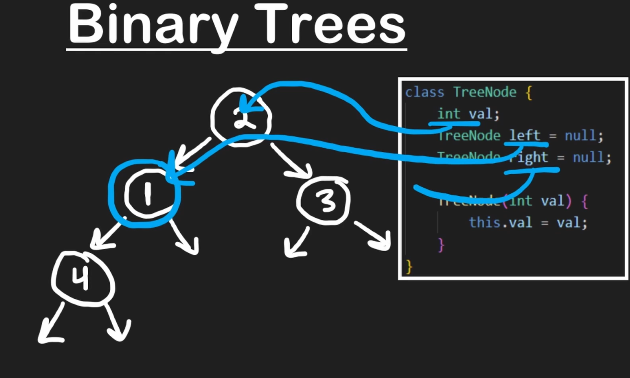

In [ ]:
def binarySearchTree(root, target):
    '''
    Time Complexity : O(n)
    sorted : all left is below root and right is more the val with root
    '''
    if not root:
        return False
    
    if target> root.val:
        return binarySearchTree(root.right, target)
    elif target < root.val:
        return binarySearchTree(root.left, target)
    else:
        return True

SyntaxError: expected '(' (3019429578.py, line 1)

In [19]:
class Solution:
    def invertTree(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        """"
        # 226. Invert Binary Tree
        Given the `root` of a binary tree, invert the tree, and return _its root_.
        
        #! Time Compelxity of code is : O(n)
        #! Space Compelxity of code is : O(h) where h is the height of the tree
        --------------------------------------------------------------------------------------
        If root is not none then swap left and right root, then apply same for left and right root and return root
        """
        if root is not None:
            print(root.val)
            mid = root.left
            root.left = root.right
            root.right = mid
            self.invertTree(root.left)
            self.invertTree(root.right)
            return root
    
    def invertTree(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        if not root:
            return None
        
        # swap the children
        root.left, root.right = root.right, root.left
        
        # make 2 recursive calls
        self.invertTree(root.left)
        self.invertTree(root.right)
        return root

In [20]:
# RECURSIVE DFS
class Solution:
    def maxDepth(self, root: TreeNode) -> int:
        if not root:
            return 0

        return 1 + max(self.maxDepth(root.left), self.maxDepth(root.right))


# ITERATIVE DFS
class Solution:
    def maxDepth(self, root: TreeNode) -> int:
        stack = [[root, 1]]
        res = 0

        while stack:
            node, depth = stack.pop()

            if node:
                res = max(res, depth)
                stack.append([node.left, depth + 1])
                stack.append([node.right, depth + 1])
        return res


# BFS
class Solution:
    def maxDepth(self, root: TreeNode) -> int:
        q = deque()
        if root:
            q.append(root)

        level = 0

        while q:

            for i in range(len(q)):
                node = q.popleft()
                if node.left:
                    q.append(node.left)
                if node.right:
                    q.append(node.right)
            level += 1
        return level


In [21]:
class Solution:
    def diameterOfBinaryTree(self, root: Optional[TreeNode]) -> int:
        if root is not None:
            self.dia= 0 
            def helper(root):
                if root is not None:
                    LC = helper(root.left)
                    LR = helper(root.right)
                    self.dia = max(self.dia, LC+LR)
                    return 1+ max(LC, LR)
                else:
                    return 0
            helper(root)
            return self.dia
        else:
            return 0

    def diameterOfBinaryTree(self, root: Optional[TreeNode]) -> int:
        res = 0

        def dfs(root):
            nonlocal res

            if not root:
                return 0
            left = dfs(root.left)
            right = dfs(root.right)
            res = max(res, left + right)

            return 1 + max(left, right)

        dfs(root)
        return res

In [22]:
class Solution:
    def isBalanced(self, root: Optional[TreeNode]) -> bool:
        self.flag = 0
        def helper(root):
            if root is not None:
                LC= helper(root.left)
                LR = helper(root.right)
                if abs(LC - LR) >1:
                    self.flag = 1
                return 1+max(LC,LR)
            else:
                return 0
        helper(root)
        if self.flag==0:
            return True
        else:
            return False

    def isBalanced(self, root: Optional[TreeNode]) -> bool:
        def dfs(root):
            if not root:
                return [True, 0]

            left, right = dfs(root.left), dfs(root.right)
            balanced = left[0] and right[0] and abs(left[1] - right[1]) <= 1
            return [balanced, 1 + max(left[1], right[1])]

        return dfs(root)[0]

In [23]:
class Solution:
    def isSameTree(self, p: Optional[TreeNode], q: Optional[TreeNode]) -> bool:
        if p is None and q is None:
            return True
        if p is None and q is not None:
            return False
        if q is None and p is not None:
            return False
        if p.val != q.val:
            return False
        return self.isSameTree(p.left, q.left) and self.isSameTree(p.right, q.right) 

################## NEETCODE APPROACH ##################
    def isSameTree(self, p: TreeNode, q: TreeNode) -> bool:
        if not p and not q:
            return True
        if p and q and p.val == q.val:
            return self.isSameTree(p.left, q.left) and self.isSameTree(p.right, q.right)
        else:
            return False

In [ ]:
class Solution:
    def isSubPath(self, head: Optional[ListNode], root: Optional[TreeNode]) -> bool:
        """"
        # 1367. Linked List in Binary Tree 
        Given a binary tree `root` and a linked list `head` of integers, return `true` _if there is a path in the tree that_ _sums up to_ `head`'s value_.
        
        >> if condition is true then check for left and right nodes traversal
        >> if not then go for basic by moving forward with left and right nodes traversal
        #! Time Compelxity of code is : O(m*n)
        --------------------------------------------------------------------------------------
        1. Base Case for Linked List Matching:
        The line if head is None: checks if the entire linked list has been traversed, indicating a full match. If this happens, the function returns True.

        2. Tree Traversal Base Case:
        The line if root is None: ensures that if the tree node is None (i.e., a leaf node), the function returns False since there can’t be a match.

        3. Recursive Tree Traversal:
        The function checks both the left and right subtrees using helper(head.next, root.left) and helper(head.next, root.right) if the current node matches the linked list node.

        4. Global Tree Traversal:
        The return helper(head, root) or self.isSubPath(head, root.left) or self.isSubPath(head, root.right) ensures that the function not only checks for matches starting at the root but also recursively checks for matches starting at every node in the tree.
        --------------------------------------------------------------------------------------
        """
        def helper(head, root):
            # If the linked list is fully traversed, return True
            if head is None:
                return True
            # If the tree node is None, return False (no match)
            if root is None:
                return False
            # If the current values of head and root match
            if head.val == root.val:
                # Try to match the rest of the linked list in both subtrees
                if helper(head.next, root.left) or helper(head.next, root.right):
                    return True
            # No match at this level
            return False
        
        # Main function to check every node in the tree
        if root is None:
            return False
        # Either the match starts at the current root or in one of its subtrees
        return helper(head, root) or self.isSubPath(head, root.left) or self.isSubPath(head, root.right)


In [24]:
class Solution:
    def isSubtree(self, root: Optional[TreeNode], subRoot: Optional[TreeNode]) -> bool:
        if not subRoot:
            return True
        if not root:
            return False
        
        def isSameTree(s, t):
            if not s and not t:
                return True
            if s and t and s.val == t.val:
                return isSameTree(s.left, t.left) and isSameTree(s.right, t.right)
            return False
        
        if isSameTree(root, subRoot):
            return True
        return self.isSubtree(root.left, subRoot) or self.isSubtree(root.right, subRoot)

################## NEETCODE APPROACH ##################
    def isSubtree(self, s: TreeNode, t: TreeNode) -> bool:
        if not t:
            return True
        if not s:
            return False

        if self.sameTree(s, t):
            return True
        return self.isSubtree(s.left, t) or self.isSubtree(s.right, t)

    def sameTree(self, s, t):
        if not s and not t:
            return True
        if s and t and s.val == t.val:
            return self.sameTree(s.left, t.left) and self.sameTree(s.right, t.right)
        return False

In [25]:
class Solution:
    def lowestCommonAncestor(self, root: 'TreeNode', p: 'TreeNode', q: 'TreeNode') -> 'TreeNode':
        def helper(root, p, stack1):
            if root is not None:
                if p == root.val:
                    stack1.append(p)
                    return stack1
                elif p > root.val:
                    stack1.append(root.val)
                    return helper(root.right, p, stack1)
                else:
                    stack1.append(root.val)
                    return helper(root.left, p, stack1)
            else:
                return stack1  

        stackp = []
        stackq = []
        stackp = helper(root, p.val, stackp)
        stackq = helper(root, q.val, stackq)

        res = 0
        
        reversed_stack1 = stackp[::-1]
        reversed_stack2 = stackq[::-1]
        set_stack1 = set(reversed_stack1)
        for value in reversed_stack2:
            if value in set_stack1:
                return TreeNode(value)

################## NEETCODE APPROACH ##################
    def lowestCommonAncestor(self, root: 'TreeNode', p: 'TreeNode', q: 'TreeNode') -> 'TreeNode':
        while True:
            if root.val < p.val and root.val < q.val:
                root = root.right
            elif root.val > p.val and root.val > q.val:
                root = root.left
            else:
                return root

In [ ]:
from collections import defaultdict

class Solution:
    def levelOrder(self, root):
        level_map = {}  # Dictionary to store nodes at each level

        def dfs(node, level):
            if not node:
                return
            # If the level is not in the dictionary, initialize with an empty list
            if level not in level_map:
                level_map[level] = []
            # Append the current node's value to the list at the current level
            level_map[level].append(node.val)
            # Traverse left and right children, increasing the level
            dfs(node.left, level + 1)
            dfs(node.right, level + 1)

        dfs(root, 0)  # Start DFS with root at level 0

        # Collect the nodes level by level in a list in order
        result = [level_map[i] for i in sorted(level_map.keys())]
        return result


class Solution:
    def levelOrder(self, root: Optional[TreeNode]) -> List[List[int]]:

        result = []
        
        def dfs(node, level):
            if not node:
                return
            # If we reach a new level not in result, append an empty list for this level
            if len(result) == level:
                result.append([])
            # Append the node's value to its corresponding level
            result[level].append(node.val)
            # Traverse left and right children, increasing the level
            dfs(node.left, level + 1)
            dfs(node.right, level + 1)

        dfs(root, 0)  # Start DFS with root at level 0
        return result

    def levelOrder(self, root: TreeNode) -> List[List[int]]:
        res = []
        q = collections.deque()
        if root:
            q.append(root)

        while q:
            val = []

            for i in range(len(q)):
                node = q.popleft()
                val.append(node.val)
                if node.left:
                    q.append(node.left)
                if node.right:
                    q.append(node.right)
            res.append(val)
        return res

In [ ]:
    #   3
    #  / \
    # 9   20
    #    /  \
    #   15   7

    # Output
    # [[9,15,7],[20],[3]]

from collections import defaultdict
### Not a Leetcode ques ###
class Solution:
    def downwardlevelOrder(self, root):
        freq_map = defaultdict(list)  # Create a defaultdict where each key's value is an empty list
        
        def helper(root):
            if not root:
                return -1
            # Compute depth
            depth = 1 + max(helper(root.left), helper(root.right))
            # Append the current node's value to the list of values for this depth
            freq_map[depth].append(root.val)
            return depth
        
        helper(root)
        
        # Collect results based on the frequency map
        result = []
        for depth in sorted(freq_map.keys()):
            result.append(freq_map[depth])
        return result


In [ ]:
from collections import deque
class Solution:
    def rightSideView(self, root: Optional[TreeNode]) -> List[int]:
        if not root:  # Handle empty tree case
            return []
        queue = deque([root])  # Initialize queue with the root node
        result = []  
        level = 0
        while queue:
            level_length = len(queue)
            for i in range(level_length):
                node = queue.popleft()
                if node.left:
                    queue.append(node.left)
                if node.right:
                    queue.append(node.right)
            result.append(node.val)

            level +=1
        return result 


class Solution:
    def rightSideView(self, root: Optional[TreeNode]) -> List[int]:
        if not root:  # Handle empty tree case
            return []
        queue = deque([root])  # Initialize queue with the root node
        result = []  
        level = 0
        while queue:
            level_length = len(queue)
            for i in range(level_length):
                node = queue.popleft()
                if i == level_length-1:
                    result.append(node.val)
                if node.left:
                    queue.append(node.left)
                if node.right:
                    queue.append(node.right)

            level +=1
        return result 

In [ ]:
class Solution:
    def goodNodes(self, root: TreeNode) -> int:
        
        def helper(root, max_val):
            if root is None:
                return 0
            
            res = 1 if root.val >= max_val else 0
            max_val = max(root.val, max_val)

            res+= helper(root.left, max_val)
            res+= helper(root.right, max_val)
            return res

        return helper(root, root.val) 


In [ ]:
# DFS
class Solution:
    def isValidBST(self, root: Optional[TreeNode]) -> bool:
        def helper(root, l, h):
            if not root:
                return True
            if not(root.val>l and root.val<h):
                return False
            return (helper(root.left, l, root.val)) and (helper(root.right, root.val, h))
        return helper(root, float("-inf"), float("inf"))  

# BFS
class Solution:
    def isValidBST(self, root: Optional[TreeNode]) -> bool:
        if not root:
            return True
        
        q = deque([(root, float('-inf'), float('inf'))])  # Queue stores (node, min_limit, max_limit)
        
        while q:
            node, low, high = q.popleft()
            
            if not (low < node.val < high):  # Check if node's value is within valid range
                return False
            
            if node.left:
                q.append((node.left, low, node.val))  # Update max limit for left child
            if node.right:
                q.append((node.right, node.val, high))  # Update min limit for right child
        
        return True


In [ ]:
class Solution:
    def kthSmallest(self, root: TreeNode, k: int) -> int:
        stack = []
        res = []
        n=0
        while stack or root:
            while root:
                stack.append(root)
                root = root.left
            root = stack.pop()
            # res.append(root)
            n=n+1
            if n == k:
                return root.val
            root = root.right
        # return res[k-1].val

In [ ]:
class Solution:
    def buildTree(self, preorder: List[int], inorder: List[int]) -> Optional[TreeNode]:
        if not preorder or not inorder:
            return None
        root = TreeNode(preorder[0])
        mid = inorder.index(preorder[0])
        root.left = self.buildTree(preorder[1:mid+1], inorder[:mid])
        root.right = self.buildTree(preorder[mid+1:], inorder[mid+1:])
        return root


class Solution:
    def buildTree(self, preorder: List[int], inorder: List[int]) -> Optional[TreeNode]:
        if not preorder or not inorder:
            return None
        
        root = TreeNode(preorder[0])
        stack = [root]
        inorder_index = 0
        
        for i in range(1, len(preorder)):
            current_val = preorder[i]
            node = TreeNode(current_val)
            
            if stack[-1].val != inorder[inorder_index]:
                stack[-1].left = node
            else:
                while stack and stack[-1].val == inorder[inorder_index]:
                    last_node = stack.pop()
                    inorder_index += 1
                last_node.right = node
            
            stack.append(node)
        
        return root

In [ ]:
class Solution:
    def maxPathSum(self, root: Optional[TreeNode]) -> int:
        max_val = float("-inf")

        def helper(root):
            nonlocal max_val

            if root is None:
                return 0
            
            leftmax = max(helper(root.left),0)
            rightmax = max(helper(root.right),0)

            # global max_val
            max_val = max(max_val, (root.val +leftmax +rightmax))

            return root.val + max(leftmax, rightmax)
        
        helper(root)
        return max_val